In [2]:
# Librerías
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# ===== CAPA LEGENDRE =====
class PolynomialLegendre(tf.keras.layers.Layer):
    def __init__(self, units, degree=2, use_bias=True, **kwargs):
        super(PolynomialLegendre, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim_leg = input_shape[-1]

        self.kernel_leg = self.add_weight(
            shape=(input_dim_leg * self.degree, self.units),
            initializer=tf.keras.initializers.GlorotUniform(),
            trainable=True,
            name="kernel_leg"
        )

        if self.use_bias:
            self.bias_leg = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True,
                name="bias_leg"
            )

    def call(self, inputs):
        # Convertimos la entrada al tipo de dato activo de la capa
        input_values = tf.cast(inputs, self.compute_dtype)

        # Valores iniciales de la recurrencia:
        # P0(x) = 1
        previous_previous_poly = tf.ones_like(input_values)

        # P1(x) = x
        previous_poly = input_values

        # Empezamos guardando el primer polinomio
        legendre_features = [previous_poly]

        # Generamos el resto de grados usando la recurrencia de Legendre
        for degree_index in range(2, self.degree + 1):
            current_degree = tf.cast(degree_index, self.compute_dtype)

            #Esto es el polinomio de Legendre pero calculado con la Recurrencia de Bonnet
            current_poly = ((2.0 * current_degree - 1.0) * input_values * previous_poly - (current_degree - 1.0) * previous_previous_poly) / current_degree

            legendre_features.append(current_poly)

            # SIguientes iteraciones
            previous_previous_poly = previous_poly
            previous_poly = current_poly

        # Unimos todas las bases polinómicas en un solo vector
        polynomial_basis = tf.concat(legendre_features, axis=-1)

        # Proyección lineal final, equivalente a una capa densa
        output_values = tf.matmul(polynomial_basis, self.kernel_leg)

        if self.use_bias:
            output_values = tf.nn.bias_add(output_values, self.bias_leg)

        return output_values


In [4]:
# ===== PLOT =====
def plot_cv_average_history_leg(histories_leg):
    max_epochs_leg = max([len(h.history['loss']) for h in histories_leg])
    epochs_leg = np.arange(1, max_epochs_leg + 1)

    def get_padded_metrics_leg(metric_name):
        matrix_leg = np.full((len(histories_leg), max_epochs_leg), np.nan)
        for i, h in enumerate(histories_leg):
            data_leg = h.history[metric_name]
            matrix_leg[i, :len(data_leg)] = data_leg
        return np.nanmean(matrix_leg, axis=0)

    avg_loss_leg = get_padded_metrics_leg('loss')
    avg_val_loss_leg = get_padded_metrics_leg('val_loss')
    avg_acc_leg = get_padded_metrics_leg('accuracy')
    avg_val_acc_leg = get_padded_metrics_leg('val_accuracy')

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_leg, avg_loss_leg)
    plt.plot(epochs_leg, avg_val_loss_leg)
    plt.title('Pérdida Promedio')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_leg, avg_acc_leg)
    plt.plot(epochs_leg, avg_val_acc_leg)
    plt.title('Precisión Promedio')

    plt.tight_layout()
    plt.show()


In [5]:
# ===== MODELO =====
def PolynomialDenseCreator_leg(degree_leg, input_dim_leg):
    inputPoli_leg = keras.Input(shape=(input_dim_leg,))
    
    x_leg = PolynomialLegendre(32, degree=degree_leg)(inputPoli_leg)
    x_leg = layers.Activation('swish')(x_leg)
    x_leg = layers.Dense(16, activation='swish')(x_leg)
    
    outputPoli_leg = layers.Dense(2, activation='softmax')(x_leg)
    
    model_leg = keras.Model(
        inputs=inputPoli_leg,
        outputs=outputPoli_leg,
        name=f"Polynomial_Model_Degree_{degree_leg}_leg"
    )
    
    model_leg.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model_leg


In [6]:
# ===== DATOS =====
magic_gamma_telescope_leg = fetch_ucirepo(id=159)

X_leg = magic_gamma_telescope_leg.data.features 
y_leg = magic_gamma_telescope_leg.data.targets 


In [7]:

# ===== HIPERPARÁMETROS =====
epochs_leg = 120
batch_size_leg = 32
input_dim_leg = X_leg.shape[1]
num_splits_leg = 10
degrees = [3, 4, 5]


In [8]:
def createEarlyStoppingCallback_leg(patience_leg=15):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience_leg,
        restore_best_weights=True
    )

In [ ]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from tqdm import tqdm

skf_leg = StratifiedKFold(n_splits=num_splits_leg, shuffle=True, random_state=1)

history_leg = {deg: [] for deg in degrees}
score_leg = {deg: [] for deg in degrees}


input_dim_leg = X_leg.shape[1]


for train_index, test_index in skf_leg.split(X_leg, y_leg):

    X_train_leg, X_test_leg = X_leg[train_index], X_leg[test_index]
    y_train_leg, y_test_leg = y_leg[train_index], y_leg[test_index]
 
    y_train_leg = (y_train_leg == 'g').astype(int)
    y_test_leg = (y_test_leg == 'g').astype(int)

    # =========================
    # 2) Validación interna estratificada
    # =========================
    X_subtrain, X_val, y_subtrain, y_val = train_test_split(
        X_train_leg,
        y_train_leg,
        test_size=0.3,
        stratify=y_train_leg,
        random_state=42
    )


 # =========================
    # 3) Normalización
    # =========================
    scaler = MinMaxScaler(feature_range=(-1, 1))

    X_subtrain = scaler.fit_transform(X_subtrain)
    X_val = scaler.transform(X_val)
    X_test_leg = scaler.transform(X_test_leg)

# =========================
# 4) Entrenamiento por grado
# =========================
    for deg in degrees:
        tf.keras.backend.clear_session()

        model = PolynomialDenseCreator_leg(deg, input_dim_leg)

        history = model.fit(
            X_subtrain,
            y_subtrain,
            validation_data=(X_val, y_val),
            epochs=epochs_leg,
            batch_size=32,
            verbose=0
        )

        test_result = model.evaluate(X_test_leg, y_test_leg, verbose=0)

        history_leg[deg].append(history)
        score_leg[deg].append(test_result)




  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [41:30<00:00, 249.01s/it]



  RESULTADOS FINALES (Promedio CV - Legendre)
Grado 3: Pérdida Promedio = 0.3327, Precisión Promedio = 0.8695


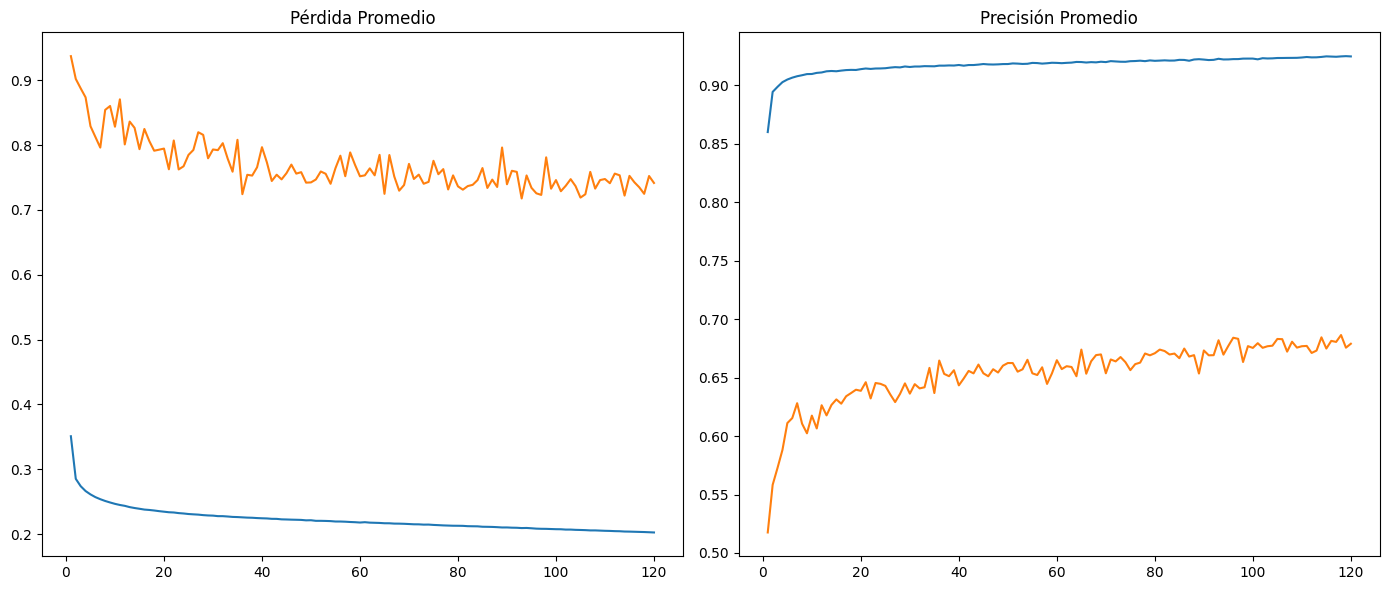

Grado 4: Pérdida Promedio = 0.3375, Precisión Promedio = 0.8723


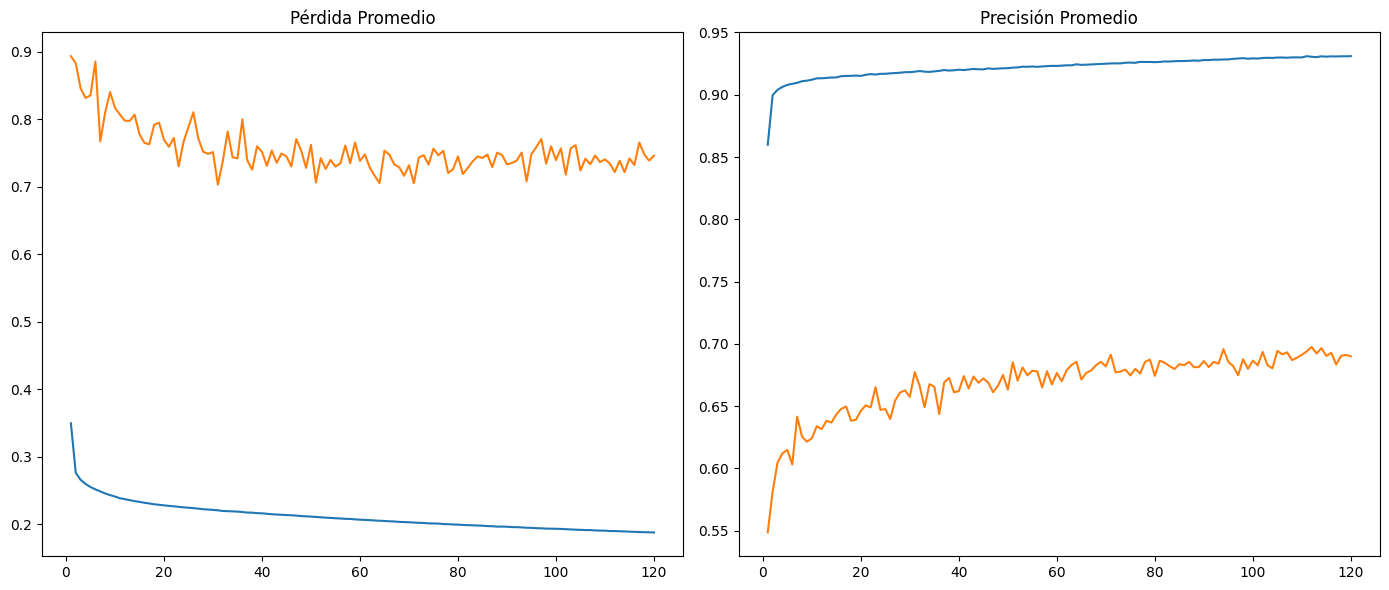

Grado 5: Pérdida Promedio = 0.3546, Precisión Promedio = 0.8707


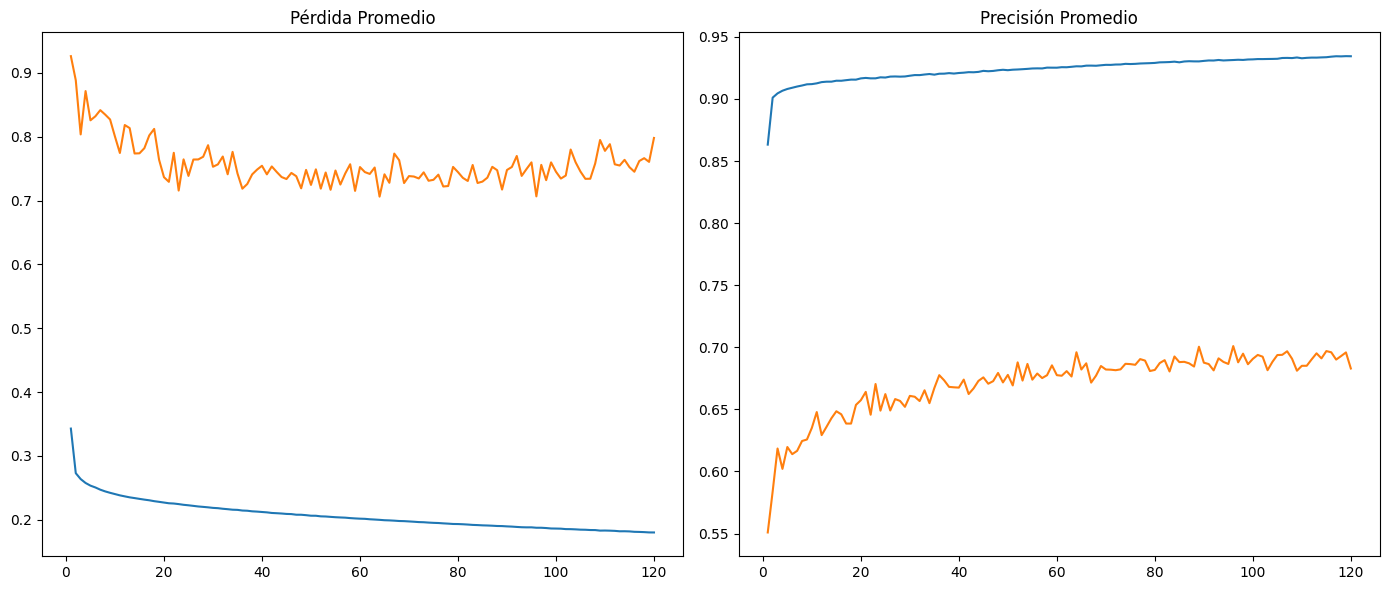

In [10]:

def calculator_leg(scores_leg):
    Totalloss_leg, Totalaccuracy_leg = 0, 0
    for loss, accuracy in scores_leg:
        Totalloss_leg += loss
        Totalaccuracy_leg += accuracy

    return Totalloss_leg/num_splits_leg, Totalaccuracy_leg/num_splits_leg


print("\n" + "="*40)
print("  RESULTADOS FINALES (Promedio CV - Legendre)")
print("="*40)

scoreMean_leg = {}
for deg in degrees:
    scoreMean_leg[deg] = calculator_leg(score_leg[deg])
    print(f"Grado {deg}: Pérdida Promedio = {scoreMean_leg[deg][0]:.4f}, Precisión Promedio = {scoreMean_leg[deg][1]:.4f}")
    plot_cv_average_history_leg(history_leg[deg])
